In [96]:
import sys
import os

# Adds the project root folder (sales-analysis-dashboard) to the path
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
from utils.dataloader import load_data

# Load the data - ensure this path is correct
df = load_data("../1_data/raw/salesdata.csv")
df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Quantity,Region,Sales,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Revenue
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0,US,00:00.0,CA-2011-130813,High,...,3,West,19,00:00.0,Second Class,4.37,California,Paper,2011,2232523
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0,US,00:00.0,CA-2011-148614,Medium,...,2,West,19,00:00.0,Standard Class,0.94,California,Paper,2011,2232543
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,00:00.0,CA-2011-118962,Medium,...,3,West,21,00:00.0,Standard Class,1.81,California,Paper,2011,2232564
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,00:00.0,CA-2011-118962,Medium,...,2,West,111,00:00.0,Standard Class,4.59,California,Paper,2011,2232585
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0,US,00:00.0,CA-2011-146969,High,...,1,West,6,00:00.0,Standard Class,1.32,California,Paper,2011,2232606


In [97]:
# Check data types and missing values
print(df.info())

# Get summary statistics for numerical columns
print(df.describe())

# Check for null values specifically
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        9998 non-null   object 
 1   City            9998 non-null   object 
 2   Country         9998 non-null   object 
 3   Customer.ID     9998 non-null   object 
 4   Customer.Name   9998 non-null   object 
 5   Discount        9998 non-null   int64  
 6   Market          9998 non-null   object 
 7   Order.Date      9998 non-null   object 
 8   Order.ID        9998 non-null   object 
 9   Order.Priority  9998 non-null   object 
 10  Product.ID      9998 non-null   object 
 11  Product.Name    9998 non-null   object 
 12  Profit          9998 non-null   float64
 13  Quantity        9998 non-null   int64  
 14  Region          9998 non-null   object 
 15  Sales           9998 non-null   int64  
 16  Ship.Date       9998 non-null   object 
 17  Ship.Mode       9998 non-null   o

In [98]:
# Convert 'Order Date' to datetime format
df['Order.Date'] = pd.to_datetime(df['Order.Date'])

# Verify the change
print(df.dtypes)


Category                  object
City                      object
Country                   object
Customer.ID               object
Customer.Name             object
Discount                   int64
Market                    object
Order.Date        datetime64[ns]
Order.ID                  object
Order.Priority            object
Product.ID                object
Product.Name              object
Profit                   float64
Quantity                   int64
Region                    object
Sales                      int64
Ship.Date                 object
Ship.Mode                 object
Shipping.Cost            float64
State                     object
Sub.Category              object
Year                       int64
Revenue                    int64
dtype: object


In [99]:
df['Month'] = df['Order.Date'].dt.month_name()
df['Year'] = df['Order.Date'].dt.year


In [100]:
# Basic overview
df.info()

# Quick statistics
df.describe()

# Check for missing values
df.isnull().sum()

# Check first few rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        9998 non-null   object        
 1   City            9998 non-null   object        
 2   Country         9998 non-null   object        
 3   Customer.ID     9998 non-null   object        
 4   Customer.Name   9998 non-null   object        
 5   Discount        9998 non-null   int64         
 6   Market          9998 non-null   object        
 7   Order.Date      9998 non-null   datetime64[ns]
 8   Order.ID        9998 non-null   object        
 9   Order.Priority  9998 non-null   object        
 10  Product.ID      9998 non-null   object        
 11  Product.Name    9998 non-null   object        
 12  Profit          9998 non-null   float64       
 13  Quantity        9998 non-null   int64         
 14  Region          9998 non-null   object        
 15  Sale

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Region,Sales,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Revenue,Month
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0,US,2026-03-15,CA-2011-130813,High,...,West,19,00:00.0,Second Class,4.37,California,Paper,2026,2232523,March
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0,US,2026-03-15,CA-2011-148614,Medium,...,West,19,00:00.0,Standard Class,0.94,California,Paper,2026,2232543,March
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,2026-03-15,CA-2011-118962,Medium,...,West,21,00:00.0,Standard Class,1.81,California,Paper,2026,2232564,March
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,2026-03-15,CA-2011-118962,Medium,...,West,111,00:00.0,Standard Class,4.59,California,Paper,2026,2232585,March
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0,US,2026-03-15,CA-2011-146969,High,...,West,6,00:00.0,Standard Class,1.32,California,Paper,2026,2232606,March


In [101]:
df = df.dropna()

In [102]:
df = df.drop_duplicates()

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set a nice style for plots
sns.set_style("whitegrid")
%matplotlib inline

In [104]:
# Basic info
df.info()

# Describe numerical columns
df.describe()

# Check for unique values in categorical columns
df['Category'].value_counts()
df['Region'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        9998 non-null   object        
 1   City            9998 non-null   object        
 2   Country         9998 non-null   object        
 3   Customer.ID     9998 non-null   object        
 4   Customer.Name   9998 non-null   object        
 5   Discount        9998 non-null   int64         
 6   Market          9998 non-null   object        
 7   Order.Date      9998 non-null   datetime64[ns]
 8   Order.ID        9998 non-null   object        
 9   Order.Priority  9998 non-null   object        
 10  Product.ID      9998 non-null   object        
 11  Product.Name    9998 non-null   object        
 12  Profit          9998 non-null   float64       
 13  Quantity        9998 non-null   int64         
 14  Region          9998 non-null   object        
 15  Sale

Region
Central           1963
South             1396
West              1203
Africa            1088
North             1028
EMEA               952
East               916
North Asia         517
Central Asia       378
Caribbean          204
Canada             143
Oceania            130
Southeast Asia      80
Name: count, dtype: int64

c:\Users\User\Downloads\sales-analysis-dashboard\venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


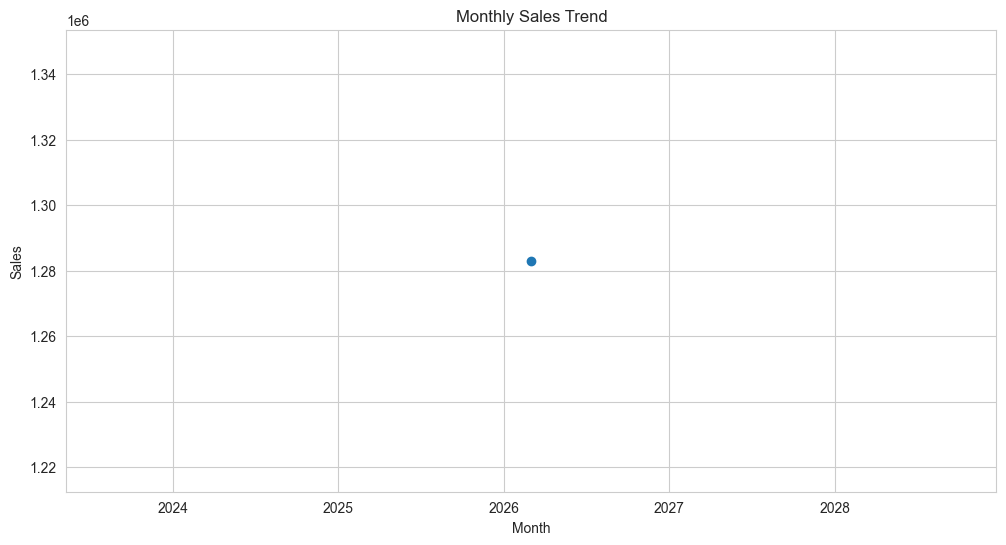

In [105]:
monthly_sales = df.groupby(df['Order.Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.show()

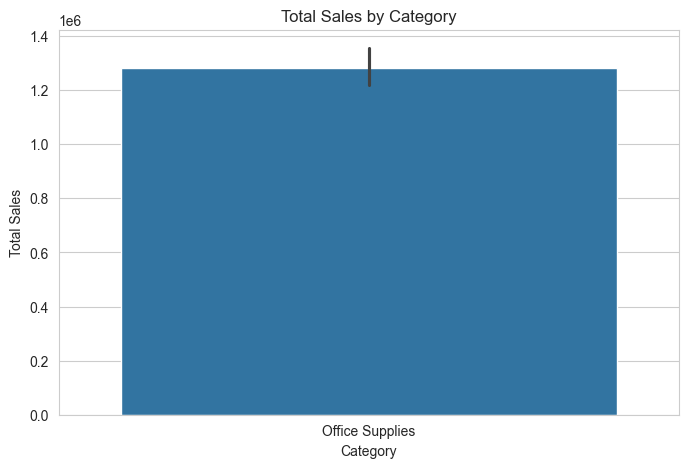

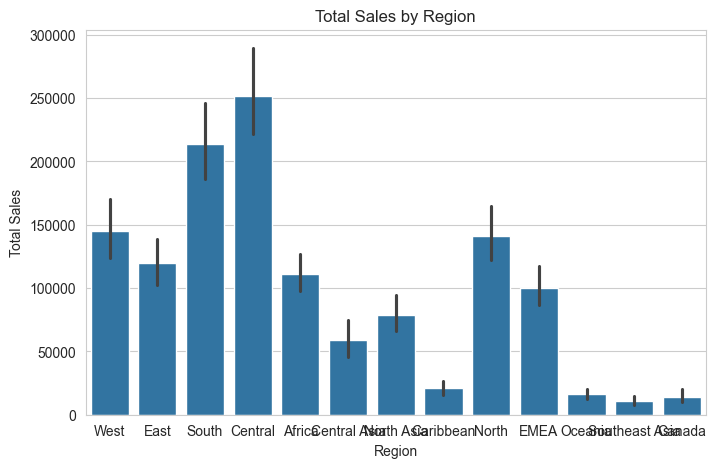

In [106]:
# Sales by category
plt.figure(figsize=(8,5))
sns.barplot(x=df['Category'], y=df['Sales'], estimator=sum)
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.xlabel("Category")
plt.show()

# Sales by region
plt.figure(figsize=(8,5))
sns.barplot(x=df['Region'], y=df['Sales'], estimator=sum)
plt.title("Total Sales by Region")
plt.ylabel("Total Sales")
plt.xlabel("Region")
plt.show()

In [107]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Revenue', 'Month'],
      dtype='object')


In [108]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Revenue', 'Month'],
      dtype='object')


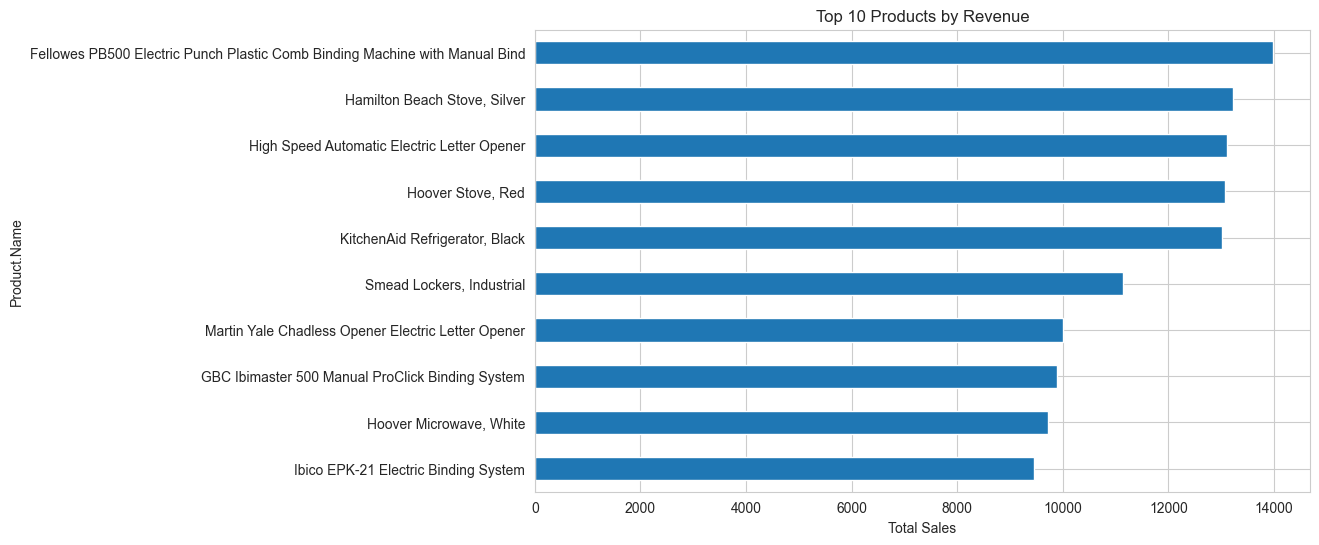

In [109]:
top_products = df.groupby('Product.Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()  # Highest on top
plt.show()

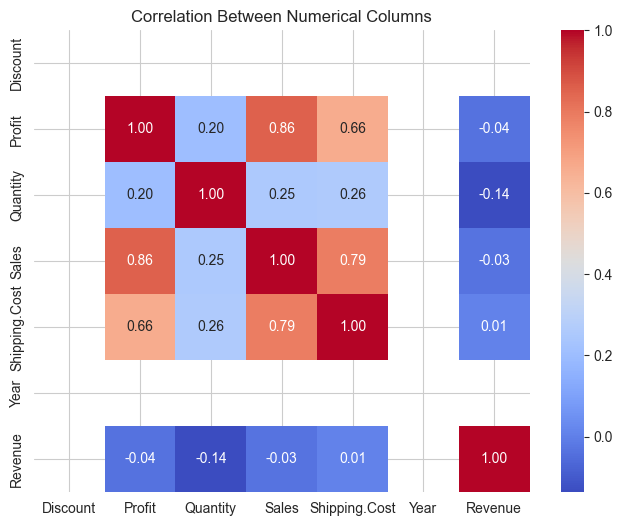

In [110]:
plt.figure(figsize=(8,6))

# numeric_only=True filters out strings like 'Office Supplies' automatically
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numerical Columns")
plt.show()


In [111]:
import plotly.express as px

fig = px.line(monthly_sales, x=monthly_sales.index.astype(str), y=monthly_sales.values,
              labels={'x':'Month','y':'Sales'}, title='Monthly Sales Trend')
fig.show()

In [112]:
df.to_csv("../1_data/processed/cleaned_sales.csv", index=False)

In [113]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Revenue', 'Month'],
      dtype='object')


In [114]:
df.isnull().sum()


Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Sales             0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Revenue           0
Month             0
dtype: int64

In [115]:
df.drop_duplicates(inplace=True)


In [116]:
# 1. Convert the column to datetime first
df['Order.Date'] = pd.to_datetime(df['Order.Date'])

# 2. Now you can extract month and year
df['Month'] = df['Order.Date'].dt.month
df['Year'] = df['Order.Date'].dt.year

# 3. Check the result
print(df[['Order.Date', 'Month', 'Year']].head())


  Order.Date  Month  Year
0 2026-03-15      3  2026
1 2026-03-15      3  2026
2 2026-03-15      3  2026
3 2026-03-15      3  2026
4 2026-03-15      3  2026


In [117]:
import streamlit as st  # Fixes the NameError
import pandas as pd
import plotly.express as px

# Load your data
# df = pd.read_csv("your_data.csv") 

# 1. Create a Sidebar for Filters
st.sidebar.header("Please Filter Here:")
region = st.sidebar.multiselect(
    "Select the Region:",
    options=df["Region"].unique(),
    default=df["Region"].unique()
)

# 2. Filter the Dataframe
df_selection = df.query("Region == @region")

# 3. Create the Chart
region_sales = df_selection.groupby("Region")["Sales"].sum().reset_index()
fig_region = px.bar(region_sales, x="Region", y="Sales", title="Sales by Region")

# 4. Display the Chart
st.plotly_chart(fig_region, use_container_width=True)



2026-03-15 22:53:55.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.416 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.428 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.449 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2026-03-15 22:53:55.782 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-15 22:53:55.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-15 22:53:55.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

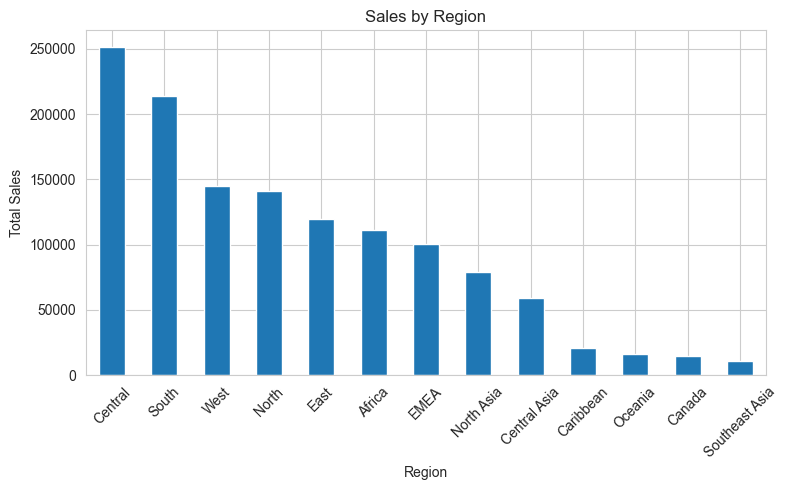

In [118]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [119]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Revenue', 'Month'],
      dtype='object')


In [120]:
# Reload using your fixed load_data function
df = load_data("../1_data/raw/salesdata.csv")

# Verify the new column appears in the list
print(df.columns) 


Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category',
       'Year', 'Revenue'],
      dtype='object')


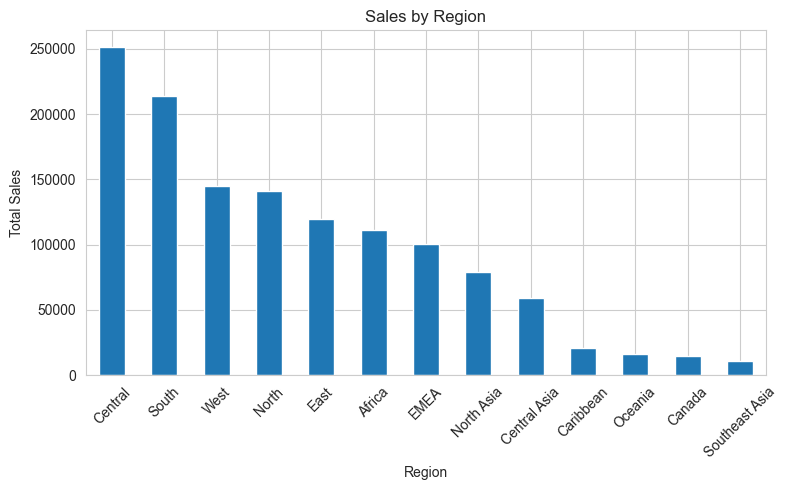

In [121]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: >

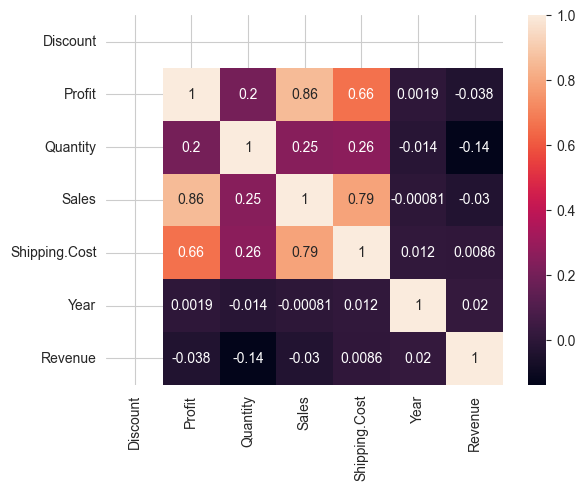

In [122]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

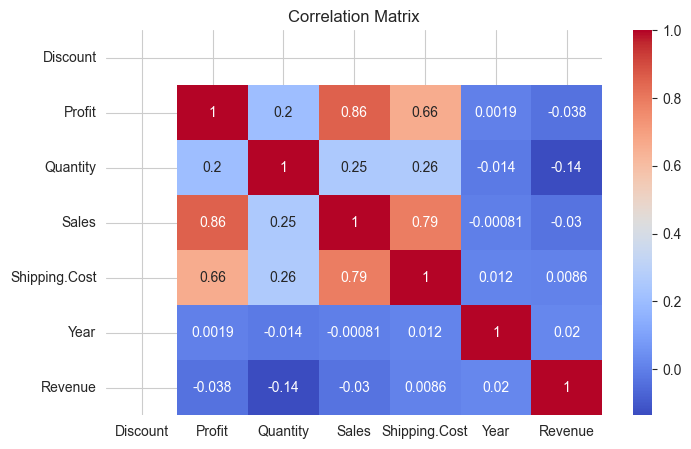

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [14]:
import pandas as pd

# Forward slashes work on Windows and are less error-prone
df = pd.read_csv("C:/Users/User/Downloads/sales-analysis-dashboard/1_data/raw/salesdata.csv")


ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [15]:
import os

path = "C:/Users/User/Downloads/sales-analysis-dashboard/1_data/raw/salesdata.csv"

if os.path.exists(path):
    print("✅ Success! Path is correct.")
else:
    # Check parts of the path to see where it fails
    base = "C:/Users/User/Downloads/sales-analysis-dashboard"
    print(f"Project folder exists: {os.path.exists(base)}")
    if os.path.exists(base):
        print(f"Contents of project: {os.listdir(base)}")


✅ Success! Path is correct.


In [17]:
import pandas as pd

def load_data(path):
    try:
        # Load dataset with 'sep=None' to auto-detect delimiters (comma, semicolon, etc.)
        df = pd.read_csv(
            path,
            encoding="latin1",
            on_bad_lines="skip", # Skips the messy rows that caused your error
            sep=None,
            engine="python"
        )

        # Clean and standardize column names
        df.columns = df.columns.str.strip().str.replace(" ", ".", regex=False)

        # Convert date column safely
        if "Order.Date" in df.columns:
            df["Order.Date"] = pd.to_datetime(df["Order.Date"], errors="coerce")

        print("✅ Success! Data loaded and cleaned.")
        return df

    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return pd.DataFrame()

# NOW CALL THE FUNCTION
file_path = r"C:/Users/User/Downloads/sales-analysis-dashboard/1_data/raw/salesdata.csv"
df = load_data(file_path)

# Show the result
if not df.empty:
    display(df.head())


✅ Success! Data loaded and cleaned.


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Quantity,Region,Sales,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Revenue
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0,US,2026-03-16,CA-2011-130813,High,...,3,West,19,00:00.0,Second Class,4.37,California,Paper,2011,2232523
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0,US,2026-03-16,CA-2011-148614,Medium,...,2,West,19,00:00.0,Standard Class,0.94,California,Paper,2011,2232543
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,2026-03-16,CA-2011-118962,Medium,...,3,West,21,00:00.0,Standard Class,1.81,California,Paper,2011,2232564
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,2026-03-16,CA-2011-118962,Medium,...,2,West,111,00:00.0,Standard Class,4.59,California,Paper,2011,2232585
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0,US,2026-03-16,CA-2011-146969,High,...,1,West,6,00:00.0,Standard Class,1.32,California,Paper,2011,2232606


In [18]:
# List all column names
print(df.columns.tolist())


['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Revenue']


C:\Users\User\AppData\Local\Temp\ipykernel_13692\3019766998.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_sub_cat, x="Sales", y="Sub.Category", palette="viridis")


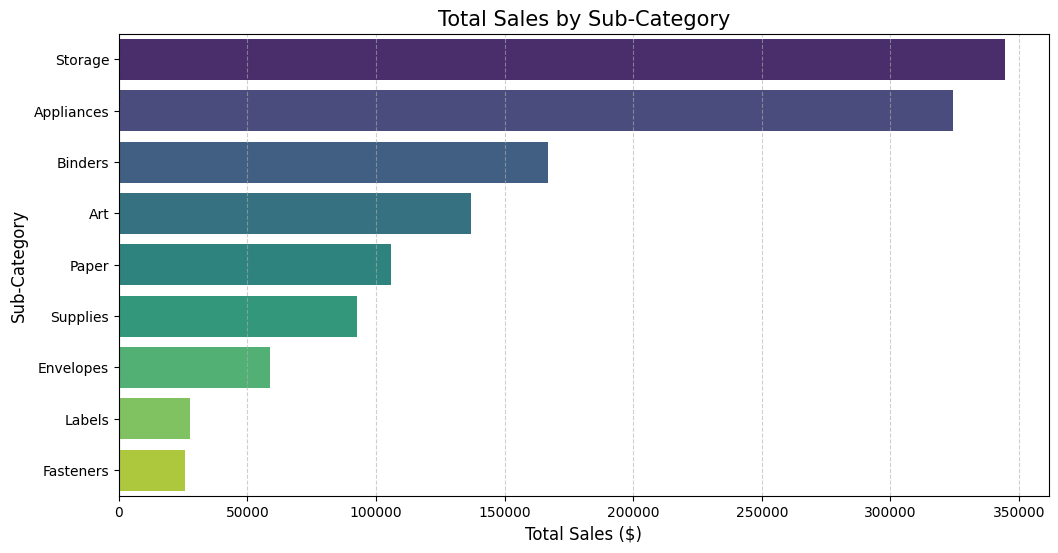

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group data and sum sales, then sort for a better visual
sales_sub_cat = df.groupby("Sub.Category")["Sales"].sum().sort_values(ascending=False).reset_index()

# 2. Create the chart
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_sub_cat, x="Sales", y="Sub.Category", palette="viridis")

# 3. Add titles and labels
plt.title("Total Sales by Sub-Category", fontsize=15)
plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()
